<div style="text-align: justify; max-width: 90ch">

# Lecture 01c: Prompts as code, roles, and structured output

**Status: Mandatory reading.**

`lec_01b` chose the model that responds. The other half is the text you send, the `prompt`.

In a chat window a `prompt` is something you type once and lose. In a system it is **code**: written as a function, versioned, tested, and its output parsed by a program, not read by a person.

**What this notebook covers**

- A prompt as a Python function with a version.
- The three **roles** (`system`, `user`, `assistant`), the one text the model actually reads, and why it has no memory.
- **Few-shot** examples: showing instead of telling.
- **Structured output**: making the model return JSON that matches a schema, so pandas can take it from there.
- **Caching** the answers, so a re-run does not call the model again.
- Streaming, for the user who is waiting.

</div>

In [1]:
import json
import os
from pathlib import Path

import ollama
import pandas as pd
from dotenv import load_dotenv

In [2]:
# --- Course configuration: edit TIER only; settings in .env (Read: 01d_env_hugging_face) ---
TIER = "cpu"  # 8-16 GB RAM, no GPU (default)
# TIER = "gpu"  # >= 8 GB VRAM: bigger, better answers (pull qwen3:8b first)

REPO = Path.cwd().resolve().parents[1]  # this notebook runs from reading_material/
load_dotenv(REPO / ".env")  # load your .env settings: OLLAMA_HOST, HF_TOKEN, ...
TIER = os.environ.get("COURSE_TIER", TIER)  # tools/run_all.py can override
os.environ.setdefault(
    "HF_HUB_DISABLE_PROGRESS_BARS", "1"
)  # no download bars in saved outputs
CHAT_MODEL = {"cpu": "qwen3:1.7b", "gpu": "qwen3:8b"}[TIER]
EMBED_MODEL = "nomic-embed-text"
OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://127.0.0.1:5010")
# To override .env in this notebook only, uncomment and edit (never a token):
# OLLAMA_HOST = "http://192.168.1.20:11434"
# MLFLOW_URI = "http://127.0.0.1:5011"
EXPERIMENT = "llm-course-01-basics"
DATA_DIR = REPO / "data"  # gitignored runtime state (indexes, caches)

from llm_course.checks import check_ollama

check_ollama(OLLAMA_HOST, [CHAT_MODEL])

Ollama OK at http://localhost:11434; models ready: qwen3:1.7b


<div style="text-align: justify; max-width: 90ch">

## 1. A prompt is a function

A prompt (`lec_01a`) is the whole text a model receives: instructions, examples, data, and the question. Once a program sends it, three problems appear:

- **Wording changes the answer.** The same question asked in slightly different ways gives different answers, so the exact text matters as much as a hyperparameter.
- **Copies drift.** A prompt pasted into three notebooks becomes three different prompts after the first edit.
- **Results need a source.** When an answer is good or bad, someone asks which prompt produced it, and nobody remembers the wording.

The fix is to put the prompt in a function with named inputs, and give it a version.

</div>

<div style="text-align: justify; max-width: 90ch">

Each part maps to something you already know:

| Prompt as code | What you already know |
| --- | --- |
| `build_prompt(question, style)` | a function: the fixed text is the body, what changes is a parameter |
| `PROMPT_VERSION = "v1"` | a parameter you would log with `mlflow.log_param`: which prompt made this result |

</div>

<div style="text-align: justify; max-width: 90ch">

We also define `ask`, a small wrapper around `client.chat` (`lec_01a`) with the course defaults, so the rest of the notebook shows the prompts,
not the plumbing:

- `think=False`: thinking off (`lec_01b`).
- `temperature` 0 and `num_predict` 200: the most likely token every time, at most 200 tokens of answer (`lec_01a`).
- `system`: an optional system message (section 2).
- `**options` collects extra keyword arguments into a dict and puts them last, so they win: section 3 calls `ask(..., num_predict=10)`.

</div>

In [3]:
client = ollama.Client(host=OLLAMA_HOST)

PROMPT_VERSION = "v1"


def build_prompt(question, style="one sentence"):
    """Wrap a student's question with the instructions we want the model to follow."""
    return f"You are answering a question from a Python course. Reply in {style}.\n\nQuestion: {question}"


def ask(prompt, system=None, **options):
    """Send one prompt (plus an optional system message) and return the answer text."""
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    response = client.chat(
        model=CHAT_MODEL,
        messages=messages,
        think=False,
        options={"temperature": 0, "num_predict": 200, **options},
    )
    return response.message.content.strip()

In [4]:
question = "What does the axis argument mean in pandas drop()?"

In [5]:
# Simple prompt: one sentence answer, no extra text
print(ask(build_prompt(question)))

The `axis` argument in pandas' `drop()` method specifies whether to drop rows or columns.


In [6]:
# More structured prompt: a bulleted list of at most one point
print(ask(build_prompt(question, style="a bulleted list of at most one point")))

- The `axis` argument in `pandas.drop()` specifies whether to drop rows or columns.  
  - `0` = drop rows (default)  
  - `1` = drop columns


In [7]:
# A new question and an open style: ask for counterpoints and caveats
print(
    ask(
        build_prompt(
            question="Should we always trust an llm response?",
            style="provide counterpoints and caveats",
        )
    )
)

**Question:** Should we always trust an LLM response?

**Counterpoints and Caveats:**

1. **Bias and Lack of Context:**  
   Large language models (LLMs) may not always understand the context or nuances of the input. They can generate responses that are factually incorrect, biased, or irrelevant to the original question.

2. **Incomplete Information:**  
   LLMs may not have access to the full context or data required to answer complex or specialized questions. This can lead to incomplete or inaccurate responses.

3. **Language and Cultural Barriers:**  
   LLMs may struggle with idioms, slang, or culturally specific references, leading to misunderstandings or misinterpretations.

4. **Security and Safety Risks:**  
   Some LLMs may generate harmful or inappropriate content, especially if the training data includes harmful or biased information. This can be a risk in sensitive or professional settings.

5. **Overreliance on AI:**  
   Over


<div style="text-align: justify; max-width: 90ch">

The first two calls share one function and change one variable, `style`. Compare what each answer says `axis` does, and whether it says which value drops what (in pandas,
`axis=0` drops rows, `axis=1` columns): the content can change, not only the layout. That is the first problem above. The third call changes the question and the style together, so it cannot tell you which change did what.
When a colleague asks "which prompt did you use?", the answer is `build_prompt`, version `v1`.

</div>

<div style="text-align: justify; max-width: 90ch">

## 2. Roles: system, user, assistant

`lec_01a` sent a list with one message, from the `user`. A chat call can send several, and each message's **role** says who wrote it ([roles](https://huggingface.co/docs/transformers/en/chat_templating) in the Hugging Face docs):

| Role | Who writes it | Typical content |
| --- | --- | --- |
| `system` | you, in your code | who the model is, rules it must follow, the language to answer in |
| `user` | the person (or your code) | the question |
| `assistant` | the model | its previous answers |

The model does not see a list. Ollama lays the messages out as one text, using the model's **chat template**: a recipe, shipped with the model, of special markers for where each message starts and who wrote it.

</div>

<div style="text-align: justify; max-width: 90ch">

For a `system` and a `user` message, with `think=False`, `qwen3:1.7b` reads this text, rendered by hand from its template (`ollama show qwen3:1.7b --template`):

```text
<|im_start|>system
You are a teaching assistant for a Python course. Answer using at most two sentences.<|im_end|>
<|im_start|>user
What does the axis argument mean in pandas drop()? /no_think<|im_end|>
<|im_start|>assistant
<think>

</think>
```

- **`<|im_start|>` and `<|im_end|>`** are special tokens (`lec_01a`) that open and close each message; the role follows the opening one.
- **The order is fixed:** the system message first, then the conversation. The text ends after `assistant`, so the likeliest continuation is the answer.
- **`/no_think` and the empty `<think>` block** were not written by us: `think=False` makes the template add them.

The optional `lec_01e` builds this text with code.

</div>

<div style="text-align: justify; max-width: 90ch">

Why a separate `system` message, when the rules could sit at the top of every question?

- **Written by you, not by the user.** The rules live in your code; the question changes with every user, the rules do not.
- **Read as directives.** Chat models are fine-tuned on conversations laid out with these roles, and treat the system message as directives on how to act.
- **Sent with every call.** The model keeps nothing between calls (below), so your code puts the system message first in every list it sends;
  the tenth call carries the rules just as the first did.

The **system prompt**, the text of the `system` message, is where product rules live: tone, language, refusals, format. `build_prompt` in section 1 put its instruction inside the user message;
the system message is the place meant for rules. Same question, two system prompts.

</div>

In [8]:
tutor = "You are a teaching assistant for a Python course. Answer using at most two sentences."

print(ask(question, system=tutor))

The `axis` argument in `pandas.drop()` specifies whether to drop the specified labels from a row (axis=0) or column (axis=1).


In [9]:
tutor_greek = tutor + " Always answer in Greek."

print(ask(question, system=tutor_greek))

Η αξία της διαταραχής στο pandas drop() είναι η επιλογή της συγκεκριμένης στήλης ή γραμμής που θέλετε να αφαιρεθεί.


<div style="text-align: justify; max-width: 90ch">

Check that the rule worked: is the second answer in Greek? The content is another matter, and it changes from run to run.
In pandas, `axis=0` drops rows:

- **In one example run** it called the argument "η διαταραχή", a disturbance, and never said which value drops rows.
- **In another run** it said 0 removes a column and 1 a row, the reverse of pandas; it also slipped on grammar ("του παραμέτρου" for "της παραμέτρου").

Check your own run the same way. Fluent-looking text, wrong meaning: the *languages* requirement from `lec_01b` failing quietly, because small models are weaker in less common languages.
A system prompt controls the form of an answer more reliably than its truth, so read the Greek answer against the English one,
and both against the pandas docs, before trusting it.

</div>

<div style="text-align: justify; max-width: 90ch">

Does the model come with a system prompt of its own, added to ours? Not from its weights, and never on top of ours:

- **Training leaves behaviour, not text.** What fine-tuning taught (follow the roles, be helpful, refuse some requests) is stored in the weights;
  no hidden text is added to your prompt.
- **A package may ship a default.** Some chat templates insert one when you send none: [Qwen2.5's](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct/blob/main/tokenizer_config.json) adds "You are Qwen,
  created by Alibaba Cloud. You are a helpful assistant." An Ollama model can carry one too ([`SYSTEM`](https://docs.ollama.com/modelfile#system);
  `ollama show <model> --system` prints it). Your system message *replaces* the default. `qwen3:1.7b` ships none.
- **Chat apps add their own.** ChatGPT or Claude.ai put a system prompt written by the company in front of your conversation.
  Through Ollama or an API, the system prompt is the one your code sends.

</div>

In [10]:
# The system message is part of the prompt: read, and paid for, on every call
for label, messages in [
    ("user only", [{"role": "user", "content": question}]),
    (
        "system + user",
        [{"role": "system", "content": tutor}, {"role": "user", "content": question}],
    ),
]:
    response = client.chat(
        model=CHAT_MODEL,
        messages=messages,
        think=False,
        options={"temperature": 0, "num_predict": 1},
    )
    print(f"prompt tokens, {label}: {response.prompt_eval_count}")

prompt tokens, user only: 26
prompt tokens, system + user: 48


<div style="text-align: justify; max-width: 90ch">

The difference between the two counts is what the `system` message added (22 tokens in one example run): `tutor` itself plus its markers.
The model reads them again on every call; a product's system prompt of a few thousand tokens is paid on every turn of every conversation,
in time on a laptop and in money on a hosted model.

Now the part that surprises everyone: **the model has no memory**. Every call starts from nothing; a conversation exists only because your code sends the previous messages again, with the `assistant` role.

</div>

In [11]:
# WRONG: the second question alone; the model has never seen the first exchange
follow_up = "Can you show a one-line example of it?"
print(ask(follow_up, system=tutor))

Sure! Here's a one-line example: `print("Hello, world!")`


In [12]:
# RIGHT: resend the history, then the follow-up
history = [
    {"role": "system", "content": tutor},
    {"role": "user", "content": question},
    {"role": "assistant", "content": ask(question, system=tutor)},
    {"role": "user", "content": follow_up},
]

response = client.chat(
    model=CHAT_MODEL,
    messages=history,
    think=False,
    options={"temperature": 0, "num_predict": 200},
)

print(response.message.content.strip())

For example: `df.drop(axis=1, labels=['column1', 'column2'])` removes columns from the DataFrame.


<div style="text-align: justify; max-width: 90ch">

Read the two answers. Alone, the model cannot know what "it" is: check whether the answer is about `drop()` at all. In one example run it invented `print("Hello, world!")` rather than ask.
With the history, look for an example of `axis` in `drop()`. The `assistant` message was regenerated here with `ask`; a real application stores the answer it already showed.

Chat applications do exactly this behind the scenes, which is why long conversations get slower and eventually hit the context window from `lec_01a`:
every turn resends every earlier token, and a hosted model bills them again each time.

</div>

<div style="text-align: justify; max-width: 90ch">

Everything one call sends becomes a single text, and the model reads all of it, every call:

| Part | Written by | In this notebook |
| --- | --- | --- |
| role markers | the chat template | added by Ollama |
| system message | your code | `tutor` |
| earlier messages | your code, from what it stored | `history` |
| the new user message | your code, often through a function | `build_prompt(question)` |
| `/no_think`, empty `<think>` | the chat template, from `think=False` | `ask` |

Sections 3 and 4 put more inside the user message, worked examples and category definitions; lecture 2 adds course notes found by a search.

</div>

<div style="text-align: justify; max-width: 90ch">

## 3. Few-shot examples

Describing a format in words works less well than showing it. A **shot** is one worked example, a question with its answer, placed inside the prompt:

| Name | The prompt contains |
| --- | --- |
| **zero-shot** | the instruction only |
| **few-shot** | the instruction plus a few worked examples |

It works because a model predicts text from the text before it (`lec_01a`): after three `Question:` / `Category:` pairs and a fourth `Question:`,
the likeliest reply follows the pattern and names a category. The price is tokens: the examples travel with every call. Here the task is to tag a student's forum question with one category.

</div>

In [13]:
FEW_SHOT = """Tag the question with exactly one category: pandas, plots, sklearn, python-basics, or other.

Question: How do I read an Excel file into a DataFrame?
Category: pandas

Question: Why does my for loop print the last value only?
Category: python-basics

Question: Which metric should I use for an imbalanced classification?
Category: sklearn

Question: {question}
Category:"""

print(
    ask(
        FEW_SHOT.format(question="How do I change the colours in a seaborn heatmap?"),
        num_predict=10,
    )
)

Category: pandas


<div style="text-align: justify; max-width: 90ch">

Read the answer: the right tag is `plots`, because a seaborn heatmap is a chart. In example runs the model answered `pandas`, or repeated the question.
Look at what the prompt gave the model:

- **Examples for three categories only.** `pandas`, `python-basics` and `sklearn` have one each; `plots` and `other` have none.
- **Names without meanings.** Nothing says that seaborn belongs to `plots`.

Section 4 adds a one-line definition per category; check whether section 5 then tags both chart questions as `plots`. Whatever your answer looks like, free text does not keep to a format, which is the next problem.

</div>

<div style="text-align: justify; max-width: 90ch">

## 4. Structured output

The answer above is text. To count categories, filter them, or plot them, a program has to **parse** it, turn the text into values it can use,
and text parsing breaks the day the model adds a word.

</div>

In [14]:
# WRONG: parse free text and hope the format never changes
raw = ask(
    FEW_SHOT.format(question="My notebook kernel keeps dying when I load a big CSV"),
    num_predict=20,
)

print(repr(raw))

category = (
    # split on the last colon, strips whitespace and periods, and lowercase the result
    raw.split(":")[-1].strip().strip(".").lower()
)  # breaks on "Category: **pandas** (probably)" or a two-line answer

print(category)

'Category: pandas'
pandas


<div style="text-align: justify; max-width: 90ch">

If it printed a clean category, it worked this time. It works until the model answers `Category: **pandas** (probably)`,
or adds a second line, and then a `KeyError` appears three cells later in a `groupby`.

The fix is **structured output**: the model answers in a fixed, machine-readable format instead of prose. The usual format is [JSON](https://www.json.org/json-en.html), the text format web services exchange;
MLflow's model serving used it in lecture 13 of the Python course. `json.loads`, from Python's [`json`](https://docs.python.org/3/library/json.html) module,
turns JSON text into Python values:

| JSON | Python |
| --- | --- |
| object `{"key": value}` | `dict` |
| array `[1, 2]` | `list` |
| string, number | `str`, `int` or `float` |
| `true`, `false`, `null` | `True`, `False`, `None` |

</div>

<div style="text-align: justify; max-width: 90ch">

Structured output tells the model the *shape* of the answer, not the wording. A [**JSON schema**](https://json-schema.org/learn/getting-started-step-by-step) is a dictionary that describes a JSON object;
`TAG_SCHEMA` below uses five of its keywords:

| Keyword | Means |
| --- | --- |
| `type` | what a value is: `object` (a dict), `string`, `boolean` |
| `properties` | the keys the object may have, each with its own `type` |
| `required` | the keys it must have |
| `enum` | the only allowed values, spelled exactly ([reference](https://json-schema.org/understanding-json-schema/reference/enum)) |
| `description` | a note on what the value should be; [not a rule](https://json-schema.org/understanding-json-schema/reference/annotations) |

</div>

<div style="text-align: justify; max-width: 90ch">

Ollama takes the schema as `format=` ([structured outputs](https://docs.ollama.com/capabilities/structured-outputs)). At each step the model gives every token a probability (`lec_01a`);
with a schema, Ollama allows only the tokens that keep the answer valid against it, so the model picks among those. This is called **constrained decoding**:
the output is valid JSON of that shape, with no parsing code, as long as `num_predict` leaves room to finish it. A cut-off answer is cut-off JSON, and `json.loads` fails.

The prompt still matters. `CATEGORIES` gives each category a one-line definition, and there are no examples this time: a zero-shot prompt, because the schema now enforces the format.

</div>

In [15]:
CATEGORIES = """Categories:
- pandas: DataFrames, reading files, merging, grouping, missing values
- plots: charts and figures (matplotlib, seaborn, plotly)
- sklearn: models, metrics, train/test split, GridSearchCV, pipelines
- python-basics: syntax, loops, functions, errors, installing packages, the command line
- other: anything else (deployment, tools, accounts)"""

TAG_SCHEMA = {
    "type": "object",
    "properties": {
        "category": {
            "type": "string",
            "enum": ["pandas", "plots", "sklearn", "python-basics", "other"],
        },
        "needs_code": {"type": "boolean"},
        "summary": {
            "type": "string",
            "description": "the question in at most ten words",
        },
    },
    "required": ["category", "needs_code", "summary"],
}


def tag_question(question):
    """Return a dict with category, needs_code, summary for one forum question."""
    response = client.chat(
        model=CHAT_MODEL,
        messages=[
            {
                "role": "user",
                "content": f"Tag this Python-course forum question with one category.\n\n{CATEGORIES}\n\nQuestion: {question}",
            }
        ],
        format=TAG_SCHEMA,  # RIGHT: the model must return JSON matching the schema
        think=False,
        options={"temperature": 0, "num_predict": 100},
    )
    return json.loads(response.message.content)


tag_question("My while loop never stops, what did I do wrong?")

{'category': 'python-basics',
 'needs_code': False,
 'summary': 'Identifies the issue with an infinite while loop in Python.'}

<div style="text-align: justify; max-width: 90ch">

`json.loads` turned the text into a dict; JSON's `true` or `false` became Python's `True` or `False`. The `enum` guarantees the category is one of your five, spelled your way.
The category *definitions* in the prompt do the other half of the work: in one example run without them, a small model tagged most questions as `python-basics`.

Now the `summary`. The schema's `description` asks for at most ten words: count the words above. Nothing enforces the limit:
in one example run with this same prompt, more than half of a dozen questions got summaries longer than ten words, one of them 51 words long.
The next cell shows why the rule is luck.

</div>

In [16]:
# Does the schema reach the prompt? Count the prompt tokens with and without it
check = [
    {
        "role": "user",
        "content": f"Tag this Python-course forum question with one category.\n\n{CATEGORIES}\n\nQuestion: My while loop never stops, what did I do wrong?",
    }
]

for label, schema in [("with the schema", TAG_SCHEMA), ("without it", None)]:
    response = client.chat(
        model=CHAT_MODEL,
        messages=check,
        format=schema,
        think=False,
        options={"temperature": 0, "num_predict": 1},
    )
    print(f"prompt tokens {label}: {response.prompt_eval_count}")

prompt tokens with the schema: 121
prompt tokens without it: 121


<div style="text-align: justify; max-width: 90ch">

If the two counts are the same, as with the Ollama versions this course was tested on, the schema did not reach the prompt:
`prompt_eval_count` (`lec_01a`) is what the model read, and the schema added nothing to it. Ollama uses the schema only to restrict which tokens may come next (constrained decoding, above).
So the `enum` works, because it limits the tokens, and the `description` does nothing, because the model never reads it.

A rule the model must follow belongs in the prompt. Ollama's [docs](https://docs.ollama.com/capabilities/structured-outputs) also suggest repeating the schema there.

</div>

In [17]:
# RIGHT: a rule the model must follow goes in the prompt; the schema only fixes the shape
TAG_PROMPT_VERSION = "v2"  # v1 had the ten-word rule only in the schema's description


def tag_question(question):
    """Return a dict with category, needs_code, summary for one forum question."""
    response = client.chat(
        model=CHAT_MODEL,
        messages=[
            {
                "role": "user",
                "content": (
                    "Tag this Python-course forum question with one category, "
                    "and summarise it in at most ten words.\n\n"
                    f"{CATEGORIES}\n\nQuestion: {question}"
                ),
            }
        ],
        format=TAG_SCHEMA,
        think=False,
        options={"temperature": 0, "num_predict": 100},
    )
    return json.loads(response.message.content)


tag_question("My while loop never stops, what did I do wrong?")

{'category': 'python-basics',
 'needs_code': True,
 'summary': 'While loop not terminating due to missing condition'}

<div style="text-align: justify; max-width: 90ch">

With the rule in the prompt, count the words again: in one example run the summary had eight, "While loop not terminating due to missing condition".
Section 5 uses this version; check whether all twelve of its summaries keep to ten words.

The edit raised `TAG_PROMPT_VERSION` to `"v2"`, because a prompt change can change every answer, not only the one you aimed at:
in one example run this edit also moved two questions from wrong categories to `sklearn`. Section 5 puts that version into the name of its cache.

</div>

<div style="text-align: justify; max-width: 90ch">

## 5. From answers to a DataFrame

Twelve real-looking forum questions, one call each, straight into pandas. `{"question": q, **tag_question(q)}` builds one dict per question (`**` unpacks the tagged dict into the new one),
and `pd.DataFrame` turns a list of dicts into a table, one row per dict. The schema is what makes this safe: every answer has the same three keys, so every row has the same columns.

</div>

<div style="text-align: justify; max-width: 90ch">

The results are **cached**: the first run saves them to a CSV in `data/`, and every later run reads the file instead of calling the model.
Why cache model answers:

- **Time.** Every call runs the model; reading the file takes milliseconds.
- **Cost.** A hosted model bills every call by the token (`lec_01a`), and every re-run pays again.
- **Reproducibility.** Temperature 0 is only nearly deterministic (`lec_01a`), and models get updated; in one example run, calling again changed one of the twelve categories.

</div>

<div style="text-align: justify; max-width: 90ch">

The catch: an answer is valid only for the model and the prompt that produced it. Both go into the file name, `lec_01c_tags_qwen3-1.7b_v2.csv`,
so switching `TIER` or raising `TAG_PROMPT_VERSION` starts a new file. Edit the prompt without raising the version, and you read old answers.

⏱ **Skip if running long.**

In one example run on a laptop CPU the twelve calls took about 30 seconds; the cached CSV in `data/` (if present) is used instead.

</div>

In [18]:
forum_questions = [
    "How do I merge two DataFrames on a customer id?",
    "Why is my bar chart showing the categories in the wrong order?",
    "What is the difference between fit and fit_transform?",
    "My while loop never stops, what did I do wrong?",
    "How can I drop rows with missing values only in one column?",
    "Which plot shows the relationship between two numeric columns?",
    "GridSearchCV takes forever, how do I make it faster?",
    "What does if __name__ == '__main__' do?",
    "Can I deploy my Gradio app without a credit card?",
    "How do I group by month and sum the sales?",
    "Is accuracy a good metric when one class is rare?",
    "The pip install command says permission denied",
]

# One file per model and prompt version, so changing either starts a new cache
# (":" is replaced because Windows does not allow it in file names).
cache_path = (
    DATA_DIR / f"lec_01c_tags_{CHAT_MODEL.replace(':', '-')}_{TAG_PROMPT_VERSION}.csv"
)
DATA_DIR.mkdir(exist_ok=True)

if cache_path.exists():
    tagged = pd.read_csv(cache_path)
else:
    tagged = pd.DataFrame([{"question": q, **tag_question(q)} for q in forum_questions])
    tagged.to_csv(cache_path, index=False)

tagged

,question,category,needs_code,summary
0,How do I merge two DataFrames on a customer id?,pandas,True,Merge DataFrames on customer ID
1,Why is my bar chart showing the categories in ...,plots,False,Bar chart categories not in correct order
2,What is the difference between fit and fit_tra...,pandas,True,Explain fit vs fit_transform in pandas
3,"My while loop never stops, what did I do wrong?",python-basics,True,While loop not terminating due to missing cond...
4,How can I drop rows with missing values only i...,pandas,True,Drop rows with missing values in a specific co...
5,Which plot shows the relationship between two ...,plots,True,Shows relationship between two numeric columns
6,"GridSearchCV takes forever, how do I make it f...",sklearn,True,Speed up GridSearchCV with optimizations
7,What does if __name__ == '__main__' do?,python-basics,True,Explains the purpose of the __main__ check in ...
8,Can I deploy my Gradio app without a credit card?,other,True,Can I deploy my Gradio app without a credit card?
9,How do I group by month and sum the sales?,pandas,True,Group by month and sum sales using pandas


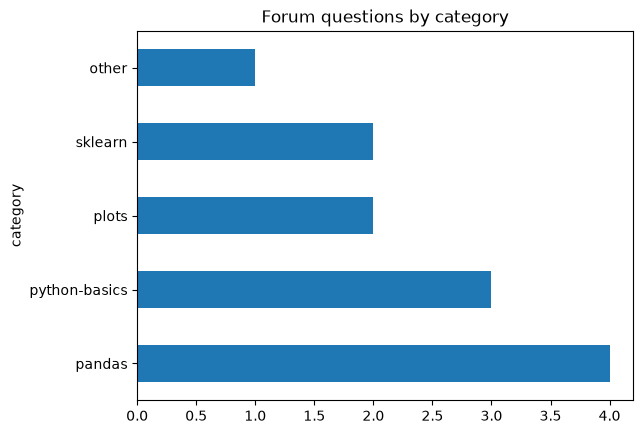

In [19]:
tagged["category"].value_counts().plot(
    kind="barh", title="Forum questions by category"
);

<div style="text-align: justify; max-width: 90ch">

### ⏸ Pause point

Look at the rows, not the plot: would you have tagged each one the same way? Check row 2, "What is the difference between fit and fit_transform?":
both methods belong to scikit-learn, yet in one example run it was tagged `pandas`, and its summary even added "in pandas".
Then look at `needs_code`. Does row 5, "Which plot shows the relationship between two numeric columns?", need code, or one word:
a scatter plot? Where you disagree with the model is exactly where lecture 3 starts: measuring how often it is right.

</div>

<div style="text-align: justify; max-width: 90ch">

## 6. Streaming

Everything so far waited for the full answer. A model writes one token at a time (`lec_01a`), so a long answer keeps a person looking at an empty screen:
at the 10-25 tokens per second of `lec_01a`'s example runs on a laptop CPU, a 500-token answer takes 20 seconds or more.
**Latency**, how long the user waits, is one of the requirements of `lec_01b`, and streaming changes which wait counts:

| Mode | The user sees | The wait that counts |
| --- | --- | --- |
| without streaming | nothing, then the whole answer | time to the last token |
| `stream=True` | the first words, then the rest as they are generated | **time to first token** |

The total time is the same; the answer only starts sooner.

</div>

<div style="text-align: justify; max-width: 90ch">

`stream=True` makes `client.chat` return the answer as a sequence of **chunks** instead of one response ([streaming](https://docs.ollama.com/capabilities/streaming)).
A `for` loop receives each chunk as it is generated, and `chunk.message.content` holds its new text. In `print`, `end=""` keeps the pieces on one line,
and `flush=True` shows each one at once instead of holding it in a buffer.

</div>

In [20]:
stream = client.chat(
    model=CHAT_MODEL,
    messages=[
        {
            "role": "user",
            "content": build_prompt(
                "Why do we split data before scaling it?",
                style="about 500 words, with a short code example",  # long enough to watch it arrive
            ),
        }
    ],
    think=False,
    stream=True,
    options={"temperature": 0, "num_predict": 1000},
)

for chunk in stream:
    print(chunk.message.content, end="", flush=True)

print()

Split

ting

 data

 before

 scaling

...

 by

 the

 scaling

 process

.

<div style="text-align: justify; max-width: 90ch">

Each chunk above is about one token: look for a word that arrived in pieces (in one example run, `Split` and `ting`), the way the tokenizer cut it (`lec_01a`).
Run the cell and watch: the first words appear at once, the rest keep coming for as long as the model writes.

Read what arrived, too; it changes from run to run. Is the scaler fitted on the training rows only, then applied to the test rows?
Would the code run? Is the reason right?

- **In example runs** the code was sometimes right and sometimes forgot an import (`train_test_split`).
- **The reasons varied more**: feature ranges and interpretability, categorical features, or data leakage put backwards;
  one run said decision trees are sensitive to scale, which they are not.

The real reason is data leakage (the first question of `lec_01a`): a scaler fitted on all rows has seen the test set's mean and spread.
Streaming changes when words appear, not whether they are right.

</div>

<div style="text-align: justify; max-width: 90ch">

When to stream:

- **A person is watching**, as in a chat window: stream.
- **A program reads the answer**, as in section 5's tagging: no gain, nothing happens until the whole answer is there.
- **The answer is JSON**: `json.loads` needs the complete text, so stream only to show progress.

To keep a streamed answer, for the history of section 2, join the chunks yourself.

</div>

<div style="text-align: justify; max-width: 90ch">

## Recap

- A **prompt** is code: a function with named inputs and a version.
- Messages have **roles**; the chat template turns them into one text, and the model reads all of it on every call.
- The **system prompt** carries the product rules; it is yours, it replaces any default, and it is paid for on every call.
- The model remembers nothing: your code resends the history.
- **Few-shot** examples show the format; definitions say what each category means.
- **Structured output** (`format=` a JSON schema) fixes the shape of an answer, its keys, types and `enum` values, not its content:
  read the rows.
- The model never reads the schema: a rule such as "at most ten words" goes in the prompt.
- **Cache** model answers for time, cost and reproducibility, under a name that carries the model and the prompt version.
- `stream=True` shows the first words sooner; the total time is the same.

**Next: `lec_01d`**, the same ideas with LangChain, a library that names these parts (prompt template, chain, parser) and chains them.

</div>